# QNN MNIST Classification（Pennylane + sklearn）
使用 QNN 來進行手寫數字 0,1,2,3 的分類。

# 1️⃣ 安裝套件（Colab）

In [21]:
!pip install pennylane          # PennyLane 是一個專門為「量子計算」設計的開源 Python 軟體庫
!pip install scikit-learn       # 用於處理一些傳統機器學習的任務，包含一些基礎的資料讀取分割功能 (後續程式碼將會使用到)

# 2️⃣ 匯入必要函式庫

In [22]:
import matplotlib.pyplot as plt                         # 在這裡用於畫折線圖、顯示圖片

from sklearn.datasets import fetch_openml               # 用於讀取 MNIST 數據
from sklearn.decomposition import PCA                   # 用於數據降維
from sklearn.model_selection import train_test_split    # 用於資料自動分割
from sklearn.preprocessing import MinMaxScaler          # 用於縮放數據範圍
from skimage.transform import resize                    # 調整圖片長寬大小
from sklearn.metrics import confusion_matrix

import pennylane as qml                                 # pennylane 量子模型庫
from pennylane import numpy as np                       # pennylane 自帶的 numpy 庫，numpy 大幅改善了 python 數值計算緩慢的問題

# 3️⃣ Data 數據
MNIST (Modified National Institute of Standards and Technology database) 是一個大型的手寫數字資料庫。包含 0 到 9 的手寫數字圖片。
* 訓練集 (Training Set)：60,000 張
* 測試集 (Test Set)：10,000 張
* 解析度：原始尺寸為 $28 \times 28$ 像素的圖片。
* 色彩：灰階 (Grayscale)。每個像素的值介於 $0$（黑色）到 $255$（白色）之間。

In [23]:
# 1. 載入並預處理資料
print("正在下載並處理 MNIST 資料...")
mnist = fetch_openml(name='mnist_784', version=1)
X_raw, y_raw = mnist.data, mnist.target

正在下載並處理 MNIST 資料...


# 4️⃣ 選擇分類任務：0 vs 1 vs 2 vs 3（四元分類）

In [1]:

# 只篩選手寫數字 0 1 2 3
mask = np.isin(y_raw, ['0', '1', '2', '3'])
X, y = X_raw[mask], y_raw[mask].astype(int)

print("X data shape: ", X.shape)
print("y data shape: ", y.shape)

# 查看手寫數字圖片
num_of_img = 10
fig, ax = plt.subplots(1, num_of_img, figsize=(2*num_of_img, 2))
for i in range(num_of_img):
    ax[i].imshow(X[i].reshape(28, 28), cmap='gray')
    ax[i].set_xticks([])
    ax[i].set_yticks([])


NameError: name 'np' is not defined

# 5️⃣ 數據預處理：
以下有兩種不同的預處理方式，分別對應到不同的資料嵌入方法。
1. 使用 PCA 將 MNIST 數據從 784(28*28) 維降維成 8 維，以避免使用到太多 qubits (因速度因素與模擬的限制)
> 這是當資料嵌入使用 Angle Embedding 時的做法，輸入的特徵長度與 qubit 數量相同。\
降維後會將數值縮放到 [0, π] 中。
2. 將 MNIST 數據的圖片從 28 * 28 的圖片縮放成 16 * 16
>   這是當資料嵌入使用 Amplitude Embedding 時的做法，因為 Amplitude Embedding 能夠支援 $2^N$ 個特徵 (N 是 qubit 的使用數量)，8 個 qubits 代表可以容納 $2^8=16*16=256$ 個特徵。



In [25]:
# Data Preprocessing
use_PCA = True  # False, True

# 1. 使用 PCA 將 MNIST 數據從 784(28*28) 維降維成 8 維，以避免使用到太多 qubits (因速度因素與模擬的限制)
if use_PCA:
    pca = PCA(n_components=8)
    Xp = pca.fit_transform(X)
    # 標準化 (將數據縮放至 [0, pi] 以符合量子閘角度範圍)
    Xp = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(Xp)

# 2. 將 MNIST 數據的圖片從 28 * 28 的圖片縮放成 16 * 16  (反白選取要註解的程式碼 -> Ctrl+/)
else:
    X_scaled = []
    X_image = X.reshape(len(X), 28, 28)   # 將 x reshape 成 [data個數, 28, 28]
    for i in range(len(X)):
        X_scaled.append(resize(X_image[i], (16, 16), anti_aliasing=True))
    Xp = np.stack(X_scaled, axis = 0).reshape(len(X_image), 256)

    # 查看手寫數字圖片
    # plt.imshow(X_scaled[0].reshape(16, 16), cmap='gray')
    # plt.show()


# 當 use_PCA 為 False 時，應該顯示 [X, 256]
# 當 use_PCA 為 True 時，應該顯示 [X, 8]
print("Xp shape:", Xp.shape)

Xp shape: (28911, 8)


In [26]:
# 切分訓練與測試集，取訓練集 1000 筆，測試集 250 筆
# PCA 降維數據，注: 當 random_state 一樣時，每次都會是切分到一樣的 data
X_train, X_test, y_train, y_test = train_test_split(Xp, y, train_size=1000, test_size=250, random_state=42)

# 縮放圖片至 16*16 數據 : 要使用時取消註解
#X_train, x_test, y_train, y_test = train_test_split(x_scaled, y, train_size=1000, test_size=250, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\n * 注意要確認數據 shape 正不正確")

X_train shape: (1000, 8)
X_test shape: (250, 8)

 * 注意要確認數據 shape 正不正確


# 6️⃣ 建構量子電路
其核心流程可分為三個階段：
1. 初始狀態準備 (State Preparation)
2. 參數化電路 (Parameterized circuit)
3. 量測 (Measurement)

如果是要做一個分類任務 (比如目前的手寫數字 0、1 分類) \
首先要先將要分類的 data 特徵丟到模型中 -> 初始狀態準備 \
目前有需多種方式可以達成此目的
1. Angle Embedding (角度嵌入)
   * 作法：將古典特徵向量 $\mathbf{x} = [x_1, x_2, ..., x_n]$ 的每一個分量映射為一個量子位元的旋轉角度(使用 $R_x, R_y$ 或 $R_z$ 閘)
    * Qubit 消耗：$N$ 個特徵需要 $N$ 個量子位元
2. ZZ Feature Map
   * 作法：除了對單個位元進行旋轉 (Angle Embedding)，還會根據兩兩特徵的乘積 (例如 $x_i \cdot x_j$ ) 施加受控相位移動（$ZZ$ 交互作用）。
    * Qubit 消耗：$N$ 個特徵需要 $N$ 個量子位元。
3. Amplitude Embedding (幅度嵌入)
    * 作法：將整個古典向量 $\mathbf{x}$ 歸一化後，直接作為量子態的機率振幅(Amplitudes)。
    * Qubit 消耗：$N$ 維特徵只需要 $\lceil \log_2 N \rceil$ 個量子位元。例如：8 維數據只需 3 個 Qubits。

接下來是分類任務的核心 -> 參數化電路
* 想要分類的好，必須要有符合數學邏輯的設計，可以看以下程式碼的範例
最後是量測
> 這個程式碼使用的是 qml.probs\
它的作用是計算量子位元在觀測後，處於各個 基態 (Basis States) 的 機率分佈。\
比如說有一個 qubit 的系統 $\vert \psi \rangle = a \vert 0 \rangle + b \vert 1 \rangle$ \
測量後，輸出的結果就會是 $[測量為 \vert 0 \rangle 的機率, 測量為 \vert 1 \rangle 的機率] = [|a|^2, |b|^2]$ \
而如果我現在有一個 2 qubit 的系統: $\vert \psi \rangle = a \vert 00 \rangle + b \vert 01 \rangle + c \vert 10 \rangle + d \vert 11 \rangle$ \
分別測量兩個 qubits 後，輸出的結果就會是 = $[|a|^2, |b|^2, |c|^2, |d|^2]$



# 以下的參數化電路是使用 HEA 結構

In [27]:

dev = qml.device("default.qubit", wires=8)  # wires=8 代表此電路可使用 8 個 qubits
@qml.qnode(dev)
def circuit_HEA(num_qubits, num_layers, weights, features):

    # 使用 PCA 的情況下，將 8 維特徵編碼到 8 個 Qubits
    if use_PCA:
        qml.AngleEmbedding(features, wires=range(num_qubits))

    # 否則將 256 維特徵編碼到 8 個 Qubits
    else:
        qml.AmplitudeEmbedding(features, wires=range(num_qubits), normalize=True)

    # 變分層 (可重複堆疊增加複雜度)
    c = 0
    for i in range(num_layers):
        # 這裡會再單個 qubit 進行一個完整的 unitary 旋轉 (可以想像成在單個 qubit 的 bloch sphere 中轉到任何方向)
        for j in range(num_qubits):
            qml.U3(weights[c], weights[c+1], weights[c+2], wires=j)
            c += 3

        # 這裡是一個全連結的糾纏層，讓 qubit 與 qubit 之間所取得的特徵進行交互
        for j in range(num_qubits - 1):
            qml.CNOT(wires=[j, j + 1])
        qml.Barrier()


    # 量測最後一個 qubit，這將會回傳有兩個數值的 list，分別是 -> [測量為 |0> 的機率, 測量為 |1> 的機率]
    return qml.probs(wires=[0, 1])

# 以下的參數化電路是使用 QCNN 結構

In [28]:

def Block(weights, wires):  # 15 個參數
    qml.U3(weights[0], weights[1], weights[2], wires=wires[0])
    qml.U3(weights[3], weights[4], weights[5], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RY(weights[6], wires=wires[0])
    qml.RZ(weights[7], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])
    qml.RY(weights[8], wires=wires[0])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.U3(weights[9], weights[10], weights[11], wires=wires[0])
    qml.U3(weights[12], weights[13], weights[14], wires=wires[1])


dev = qml.device("default.qubit", wires=8)  # wires=8 代表此電路可使用 8 個 qubits
@qml.qnode(dev)
def circuit_QCNN(num_qubits, num_layers, weights, features):
    # 使用 PCA 的情況下，將 8 維特徵編碼到 8 個 Qubits
    if use_PCA:
        qml.AngleEmbedding(features, wires=range(num_qubits))

    # 否則將 256 維特徵編碼到 8 個 Qubits
    else:
        qml.AmplitudeEmbedding(features, wires=range(num_qubits), normalize=True)

    # 變分層 (可重複堆疊增加複雜度)
    c = 0
    for i in range(num_layers):
        target_qubit = [j*(2**i) for j in range(num_qubits//(2**i))]
        for j in range(len(target_qubit)//2):
            Block(weights[c:c+15], wires = [target_qubit[j*2],target_qubit[j*2+1]])
        qml.Barrier()
        if i != 2:
            for j in range(len(target_qubit)//2):
                Block(weights[c:c+15], wires = [target_qubit[j*2+1],target_qubit[(j*2+2) % (8//(2**i))]])
        c += 15
        qml.Barrier()

    # 量測最後一個 qubit，這將會回傳有兩個數值的 list，分別是 -> [測量為 |0> 的機率, 測量為 |1> 的機率]
    return qml.probs(wires=0)

# 建構量子電路

(<Figure size 7600x900 with 1 Axes>, <Axes: >)

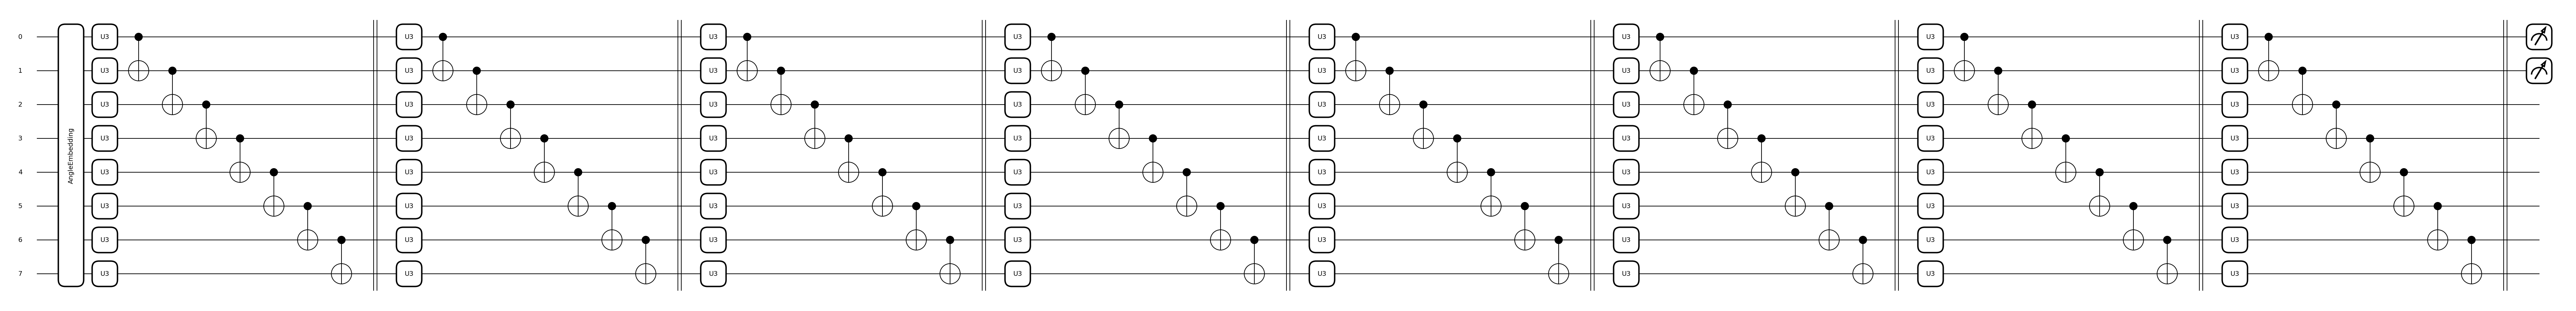

In [30]:
circuit_choose = "HEA"  # HEA or QCNN，選擇使用 HEA 還是 QCNN

# 初始化參數
num_qubits = 8  # qubit 數量，不要超過 8 個，因為前面 dev = qml.device("default.qubit", wires=8) wires 設定只能用 8 個 qubits
num_layers = 3  # 層數，如果是在 QCNN 的情況下，只能是 3

# 計算 parameter 數量
if circuit_choose == "HEA":
    # 每層使用 num_qubits * 3 個參數
    num_parameters = num_layers * num_qubits * 3
    circuit = circuit_HEA

elif circuit_choose == "QCNN":
    # QCNN 的情況下，只能是 3
    num_layers = 3

    # 每層使用 15 個參數
    num_parameters = num_layers * 15
    circuit = circuit_QCNN

# 隨機生成可訓練的參數，數值範圍 [low, high] 在 [-pi, pi] 之間，長度為 size
weights = np.random.uniform(low = -np.pi, high = np.pi, size = num_parameters, requires_grad=True)

# 畫出電路圖
qml.draw_mpl(circuit)(num_qubits, num_layers, weights, X_train[0])

# 7️⃣ 定義損失函數
QNN 與 ANN 中，損失函數 (Loss Function) 是衡量模型表現的核心工具
* Loss 是用來測量模型的預測結果與真實標籤之間的差距，所以這個數值越小越好
* 模型可以根據 Loss 來優化參數權重 (weights)，使下次的預測結果更貼近真實標籤
* 以下使用 均方誤差 (Mean Squared Error, MSE) 來進行 Loss 計算
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
預測值 ($\hat{y}$)：模型根據輸入資料算出來的答案。真實值 ($y$)：資料集標註的正確答案，n: data 的個數。\
以下是 Loss 與 weight 之間的關聯，我們需要找到的是"全局最優解"的位置 \
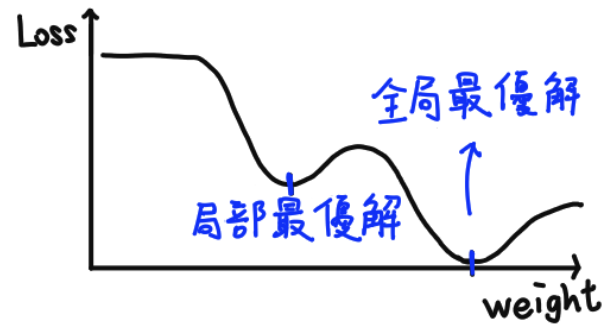



In [31]:
def loss_func(weights, x, y):
    # 測量兩個 qubit，所以會有 00 01 10 11 這幾種情況
    predictions = np.array([circuit(num_qubits, num_layers, weights, data) for data in x])
    y = np.eye(4)[y]

    # 使用平方誤差 (MSE) 損失函數 -> 用來檢測量子模型預測的與真實結果的差距，我們會希望這個數值越小越好
    loss = np.mean((predictions - y)**2)

    # 回傳損失函數
    return loss

# 8️⃣ 訓練 QNN 模型
* 優化器 (Optimizer)：在訓練 QNN 或 ANN 模型時，需要選擇合適的數學機制來更新參數權重 (Weights)，此機制即為優化器 (Optimizer)。本研究選用 AdamOptimizer，利用其自適應學習率的特性來提升優化效率。
* 學習率 (Learning Rate)：每次優化的步長。若設定過大，模型容易跳過全局最優解而產生震盪；若設定過小，則會導致收斂緩慢，且容易陷入局部最優解 (Local Minima)。
* 批次大小 (Batch Size)：考量到數據量龐大，訓練過程採用分批訓練 (Mini-batch Training)。其中 Batch Size 代表每次參數更新時所使用的樣本數量，能有效平衡計算效率與內存負荷。

In [32]:
# 4. 開始訓練。
# 注意每次執行這段程式碼後，參數會重製，所以會需要重新訓練

# 設定訓練的超參數 (控制模型學習過程的參數)
step = 40               # 訓練次數
batch_size = 8          # 每次訓練所使用的 data 數量
learning_rate = 0.01    # 每次更新參數的步長
opt = qml.AdamOptimizer(stepsize=learning_rate)     # 利用梯度下降優化器
loss_list = []                                      # 用於紀錄 loss 數值的變化

start = 0
total_step = 0

# 隨機生成可訓練的參數，數值範圍 [low, high] 在 [-pi, pi] 之間，長度為 size
weights = np.random.uniform(low = -np.pi, high = np.pi, size = num_parameters, requires_grad=True)

In [33]:
print("開始訓練量子模型...")
for i in range(start, step):
    # 隨機抽樣 batch_size 個 data
    batch_index = np.random.randint(0, len(X_train), (batch_size,))
    X_batch = X_train[batch_index]
    y_batch = y_train[batch_index]

    # loss_func 中會把每個 data 分別丟到量子電路當中，並計算 loss(損失)
    weights, loss = opt.step_and_cost(lambda w: loss_func(w, X_batch, y_batch), weights)
    loss_list.append(loss)

    if (total_step + 1) % 5 == 0:
        print(f"Step {total_step+1:3d} | Loss: {loss:.4f}")
    total_step += 1

開始訓練量子模型...


/usr/local/lib/python3.12/dist-packages/autograd/numpy/numpy_vjps.py:943: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Step   5 | Loss: 0.1779
Step  10 | Loss: 0.1646
Step  15 | Loss: 0.1522
Step  20 | Loss: 0.1494
Step  25 | Loss: 0.1335
Step  30 | Loss: 0.1243
Step  35 | Loss: 0.1217
Step  40 | Loss: 0.1347


# 9️⃣ 結果圖 ①: Test data 準確度、Loss 下降圖


測試集準確度: 86.00%


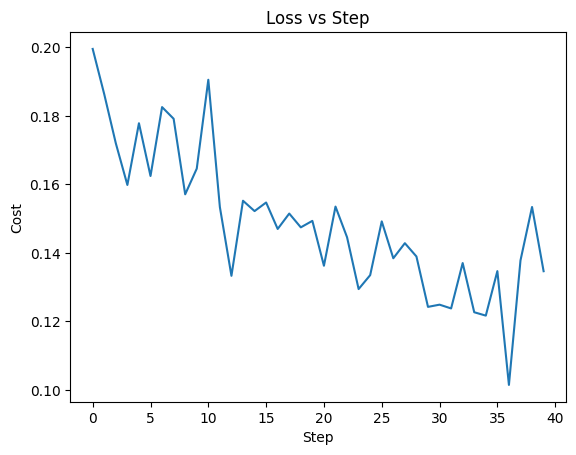

In [34]:
# 5. 測試準確度
def predict(weights, X_test):
    # 將 test data 與訓練完成的權重丟到量子模型當中，並且只拿 "測量為 |1> 的機率"
    predictions = [np.argmax(circuit(num_qubits, num_layers, weights, data)) for data in X_test]
    return predictions

y_pred = predict(weights, X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\n測試集準確度: {accuracy * 100:.2f}%")


# loss 變化折線圖 (Loss 有下降代表有在訓練)
plt.plot(loss_list)
plt.xlabel("Step")
plt.ylabel("Cost")
plt.title("Loss vs Step")
plt.show()

# 🔟 結果圖 ②: 混淆矩陣熱圖

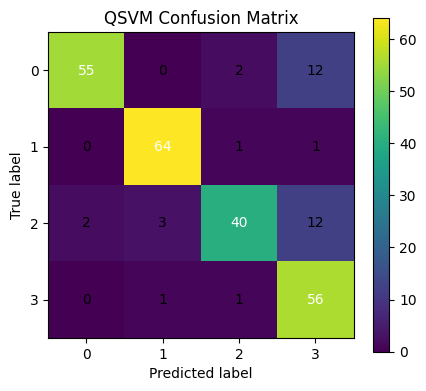

In [35]:
# 6. 混淆矩陣 (confusion matrix)
cm = confusion_matrix(y_test, y_pred)
classes = ['0', '1', '2', '3']

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("QSVM Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()